# Brain Tumor Segmentation from Multimodal MRI

This notebook develops the project in two parts:

1. **Baseline:** a classical 4D GMM using the four MRI modalities, followed by
   a validation-optimized spatial image-processing pipeline.
2. **Improved models:** boundary distance, bilateral symmetry and their combined
   representation are introduced one at a time. They use the exact image-processing
   configuration selected by the baseline, with only their probability thresholds
   recalibrated on the validation set.

The final section compares the baseline and all three improvements on the same test
volumes using the outputs required by the assignment.

## Experimental design

Each BraTS case contains T1, T1ce, T2 and FLAIR MRI modalities and a three-channel
tumor annotation. The annotation channels are combined into one binary whole-tumor
ground truth.

To reduce computation, axial slice 80 is used for every patient. At the beginning
of the notebook, all 369 patients are randomly divided into 250 training, 50
validation and 69 test patients with a fixed seed. Stratification balances
central-slice tumor-size groups and every quartile of the original patient order.
This prevents contiguous acquisition/source blocks and particular tumor sizes from
being isolated in one subset. The exact split is saved and reused by every model.
Because the converted HDF5 files do not include clinic identifiers, original-order
quartiles are used to control ordering bias; exact clinic stratification would require
the BraTS subject-to-source mapping file.

Four point-wise GMM representations are compared using exactly the same spatial
image-processing pipeline. All hyperparameters are selected exclusively on the
validation set. One shared set of structural image-processing parameters is used
for all four models, while the three probability-dependent thresholds are selected
separately for each model. The test set is evaluated once after all settings are frozen.

## Imports and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr
import optuna

from config import *

# from evaluation.evaluate_test_set import eval_dataset
# from evaluation.hyperprameter_optimization import (
#     SPATIAL_OPTIMIZATION_VERSION,
#     Z_OPTIMIZATION_VERSION,
#     run_ndi_optimization,
#     run_optimization,
#     run_z_optimization,
# )
from statistical_models.train_healthy import fit_and_save_healthy_gmm
from statistical_models.train_tumor import fit_and_save_tumor_gmm
from utilities.utils import load_and_normalize_slice
from utilities.patient_split import (
    create_or_load_patient_split,
    model_matches_training_split,
    split_summary,
)

from evaluation.boxplots_visualization import plot_segmentation_boxplots
from evaluation.scatterplot_visualization import plot_score_correlations
from evaluation.evaluate_single_slice import eval_vol
from evaluation.evaluate_test_set import dataset_eval
from evaluation.hyperparameter_optimization import (
    load_validation_parameters,
    optimize_baseline_parameters,
    optimize_model_probability_parameters,
)

from image_processing.posterior_comparison_visualization import plot_posterior_comparison

%matplotlib inline
plt.style.use("dark_background")

FIGURES_DIR = Path(PROJECT_ROOT) / "output" / "required_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Patient-level train, validation and test split

The following cell creates or loads one fixed randomized split. Patients are
stratified by central-slice tumor-size group and original-order quartile. It then
shows the subset sizes, tumor-size balance and ordering balance before any model
is trained. The split is saved to `saved_parameters/patient_split.json`.

Split ID: 7abfb7c10f61
The HDF5 files do not contain clinic identifiers. Patient-index quartiles are balanced to prevent ordered source blocks from being isolated, but this is not a substitute for true clinic metadata.


,Patients,Tumor_present,Median_tumor_pixels,Mean_tumor_pixels
split,,,,
train,250,224,1516.5,1729.9
validation,50,44,1677.0,1674.0
test,69,62,1430.0,1663.7


tumor_size_group,large,medium,no tumor,small,very large
split,,,,,
train,56,55,26,57,56
validation,10,12,6,11,11
test,16,15,7,15,16


order_quartile,0,1,2,3
split,,,,
train,63,62,63,62
validation,13,12,12,13
test,17,18,17,17


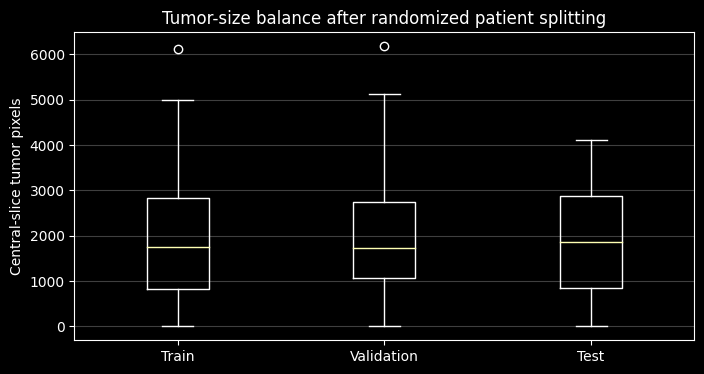

In [2]:
PATIENT_SPLIT = create_or_load_patient_split()
training_volumes = np.asarray(PATIENT_SPLIT["train"], dtype=int)
validation_volumes = np.asarray(PATIENT_SPLIT["validation"], dtype=int)
test_volumes = np.asarray(PATIENT_SPLIT["test"], dtype=int)
split_table = split_summary(PATIENT_SPLIT)

split_balance = split_table.groupby("split").agg(
    Patients=("volume", "size"),
    Tumor_present=("tumor_pixels", lambda values: int((values > 0).sum())),
    Median_tumor_pixels=("tumor_pixels", "median"),
    Mean_tumor_pixels=("tumor_pixels", "mean"),
).reindex(["train", "validation", "test"])
size_balance = pd.crosstab(
    split_table["split"], split_table["tumor_size_group"]
).reindex(["train", "validation", "test"])
order_balance = pd.crosstab(
    split_table["split"], split_table["order_quartile"]
).reindex(["train", "validation", "test"])

print("Split ID:", PATIENT_SPLIT["split_id"])
print(PATIENT_SPLIT["clinic_note"])
display(split_balance.round(1))
display(size_balance)
display(order_balance)

tumor_sizes = [
    split_table.loc[
        (split_table["split"] == subset)
        & (split_table["tumor_pixels"] > 0),
        "tumor_pixels",
    ]
    for subset in ["train", "validation", "test"]
]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(tumor_sizes, labels=["Train", "Validation", "Test"])
ax.set(
    ylabel="Central-slice tumor pixels",
    title="Tumor-size balance after randomized patient splitting",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

## 1. Preprocessing

Each modality is normalized with the corresponding volume-level mean and standard deviation. A brain mask is created from nonzero MRI pixels and eroded slightly to reduce boundary artifacts. The following visualization uses a training case, so no test annotation is inspected during model development.

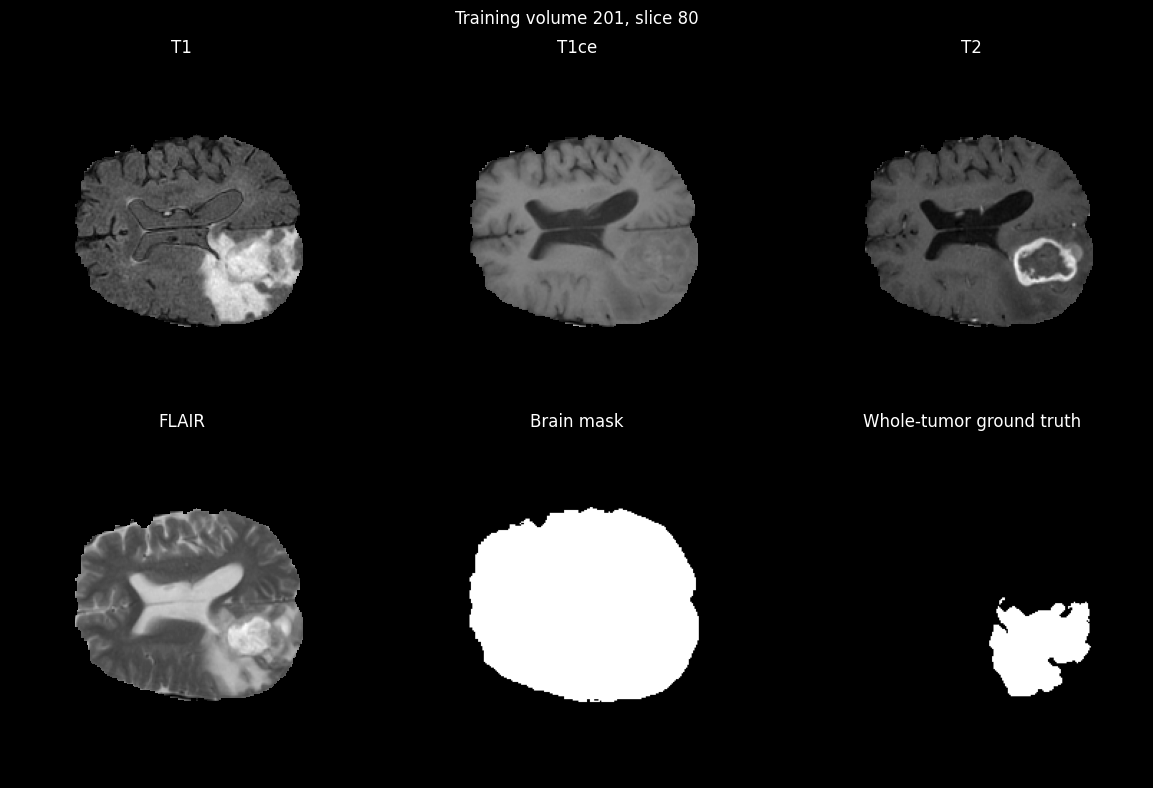

In [3]:
sample_volume = int(training_volumes[0])
sample_image, sample_brain_mask, sample_gt, _ = load_and_normalize_slice(sample_volume, SLICE_NUM)
sample_gt_binary = np.any(sample_gt > 0, axis=-1)
modality_names = ["T1", "T1ce", "T2", "FLAIR"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for channel, name in enumerate(modality_names):
    axes.flat[channel].imshow(np.where(sample_brain_mask, sample_image[:, :, channel], np.nan), cmap="gray")
    axes.flat[channel].set_title(name)
axes.flat[4].imshow(sample_brain_mask, cmap="gray")
axes.flat[4].set_title("Brain mask")
axes.flat[5].imshow(sample_gt_binary, cmap="gray")
axes.flat[5].set_title("Whole-tumor ground truth")
for ax in axes.flat:
    ax.axis("off")
fig.suptitle(f"Training volume {sample_volume}, slice {SLICE_NUM}")
plt.tight_layout()
plt.show()

## Model configurations

In [4]:
MODEL_FILES = {
    "Raw (4D)": {
        "healthy_model_file": "healthy_gmm_raw.npz",
        "tumor_model_file": "tumor_gmm_raw.npz",
    },
    "Boundary distance (5D)": {
        "healthy_model_file": "healthy_gmm_boundary_distance.npz",
        "tumor_model_file": "tumor_gmm_boundary_distance.npz",
    },
    "Symmetry (8D)": {
        "healthy_model_file": "healthy_gmm_symmetric.npz",
        "tumor_model_file": "tumor_gmm_symmetric.npz",
    },
    "Combined (9D)": {
        "healthy_model_file": "healthy_gmm_all_modalities.npz",
        "tumor_model_file": "tumor_gmm_all_modalities.npz",
    },
}

GMM_PARAMETER_TABLE = pd.DataFrame([
    {"Model": "Raw (4D)", "Feature channels": "T1, T1ce, T2, FLAIR", "Healthy K": GMM_RAW_COMPONENTS, "Tumor K per class": GMM_TUMOR_COMPONENTS},
    {"Model": "Boundary distance (5D)", "Feature channels": "MRI + boundary distance", "Healthy K": GMM_BOUNDARY_COMPONENTS, "Tumor K per class": GMM_TUMOR_COMPONENTS},
    {"Model": "Symmetry (8D)", "Feature channels": "MRI + four NDI channels", "Healthy K": GMM_SYMMETRIC_COMPONENTS, "Tumor K per class": GMM_TUMOR_COMPONENTS},
    {"Model": "Combined (9D)", "Feature channels": "MRI + NDI + boundary distance", "Healthy K": GMM_FULL_COMPONENTS, "Tumor K per class": GMM_TUMOR_COMPONENTS},
])
display(GMM_PARAMETER_TABLE)

,Model,Feature channels,Healthy K,Tumor K per class
0,Raw (4D),"T1, T1ce, T2, FLAIR",9,3
1,Boundary distance (5D),MRI + boundary distance,9,3
2,Symmetry (8D),MRI + four NDI channels,9,3
3,Combined (9D),MRI + NDI + boundary distance,9,3


## 2. Baseline model

### 2.1 Raw-intensity GMM

The baseline uses only the four normalized MRI intensities: T1, T1ce, T2 and
FLAIR. The following cell fits and saves the GMM parameters only when their
files are missing. When the fitted NPZ files already exist, they are reused.

In [5]:
raw_healthy_path = MODELS_DIR / "healthy_gmm_raw.npz"
if not model_matches_training_split(raw_healthy_path, training_volumes):
    print("Training 4D Raw Baseline GMM...")
    fit_and_save_healthy_gmm(
        num_components=GMM_RAW_COMPONENTS,
        filename="healthy_gmm_raw.npz",
        channel_indices=[0, 1, 2, 3],
        training_volumes=training_volumes,
    )

raw_tumor_path = MODELS_DIR / "tumor_gmm_raw.npz"
if not model_matches_training_split(raw_tumor_path, training_volumes):
    print("Training 4D Raw Baseline Tumor GMM...")
    fit_and_save_tumor_gmm(
        num_components=GMM_TUMOR_COMPONENTS,
        num_classes=3,
        filename="tumor_gmm_raw.npz",
        channel_indices=[0, 1, 2, 3],
        training_volumes=training_volumes,
    )

print("Baseline statistical parameters are ready.")

Baseline statistical parameters are ready.


### 2.2 Baseline spatial image processing

The baseline GMM produces point-wise posterior probabilities. A classical
image-processing pipeline converts them into a contiguous binary tumor mask:

1. Sobel edge detection on the merged tumor posterior.
2. Closed-contour extraction.
3. Entropy-weighted contour classification.
4. Region growing from accepted tumor seeds.

The structural image-processing parameters belong to the baseline. They are
optimized on the 50 stratified validation patients and then frozen for all improved models.

### 2.3 Baseline validation optimization and parameter freezing

This Optuna study jointly selects:

- Baseline image-processing parameters.
- Baseline probability thresholds.

The objective is Raw 4D mean Dice on the validation set. Trial 0 evaluates the
current configured baseline, so the optimization starts from a known reference.
Contour acceptance uses only the entropy-weighted tumor posterior score; there is no
large-contour fallback rule.
The selected values
are saved immediately to saved_parameters/validation_optimization.json.
The test set is not used for parameter selection.

In [6]:
optimization_path = Path(PROJECT_ROOT) / "saved_parameters" / "validation_optimization.json"
baseline_name = "Raw (4D)"

if optimization_path.exists():
    SELECTED_PARAMETERS = load_validation_parameters()
    baseline_ready = (
        SELECTED_PARAMETERS.get("workflow_version") == "balanced_patient_split_v1"
        and SELECTED_PARAMETERS.get("split_id") == PATIENT_SPLIT["split_id"]
        and SELECTED_PARAMETERS.get("baseline_model") == baseline_name
        and baseline_name in SELECTED_PARAMETERS.get("model_probability_params", {})
        and bool(SELECTED_PARAMETERS.get("shared_image_processing_params"))
    )
else:
    baseline_ready = False

if not baseline_ready:
    SELECTED_PARAMETERS, baseline_study = optimize_baseline_parameters(
        baseline_name=baseline_name,
        baseline_files=MODEL_FILES[baseline_name],
        validation_volumes=validation_volumes,
        split_id=PATIENT_SPLIT["split_id"],
        n_trials=60,
    )

print("Selection split:", SELECTED_PARAMETERS["selection_split"])
print(SELECTED_PARAMETERS["selection_method"])

Selection split: 50 stratified validation patients
Baseline study jointly selects image-processing parameters and baseline probability thresholds. Improved models reuse the frozen image-processing parameters and optimize only their probability thresholds.


In [7]:
baseline_image_table = pd.DataFrame(
    SELECTED_PARAMETERS["shared_image_processing_params"].items(),
    columns=["Frozen baseline image-processing parameter", "Selected value"],
)
baseline_probability_table = pd.DataFrame([
    {
        "Model": baseline_name,
        **SELECTED_PARAMETERS["model_probability_params"][baseline_name],
        "Validation mean Dice": SELECTED_PARAMETERS["model_validation_mean_dice"][baseline_name],
    }
])
display(baseline_image_table)
display(baseline_probability_table.round(4))

if "baseline_study" in globals():
    history = baseline_study.trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running best")
    plt.xlabel("Trial")
    plt.ylabel("Baseline validation Dice")
    plt.title("Baseline parameter optimization")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

,Frozen baseline image-processing parameter,Selected value
0,min_pixels_per_blob,39
1,sobel_binarization_factor,0.611372
2,allow_internal_contours,True
3,max_expansion_diameter,36


,Model,posterior_mean_threshold,entropy_expansion_threshold,posterior_expansion_threshold,Validation mean Dice
0,Raw (4D),0.3151,0.1445,0.2531,0.7031


### 2.4 Frozen baseline test result

The baseline is now fully frozen. The following test result is reported without
changing any parameter afterward.

In [8]:
SHARED_IMAGE_PARAMS = SELECTED_PARAMETERS["shared_image_processing_params"]
RESULTS = {}
MODEL_SPECS = {}

def evaluate_frozen_model(model_name):
    probability_params = SELECTED_PARAMETERS["model_probability_params"][model_name]
    MODEL_SPECS[model_name] = {
        **MODEL_FILES[model_name],
        **probability_params,
        **SHARED_IMAGE_PARAMS,
    }
    RESULTS[model_name] = dataset_eval(
        test_volumes,
        slice_num=SLICE_NUM,
        image_processing_params=SHARED_IMAGE_PARAMS,
        return_details=True,
        verbose=True,
        **MODEL_FILES[model_name],
        **probability_params,
    )
    result = RESULTS[model_name]
    display(pd.DataFrame([{
        "Model": model_name,
        "Validation Dice": SELECTED_PARAMETERS["model_validation_mean_dice"][model_name],
        "Test Dice mean": result["mean_dice"],
        "Test Dice std": result["std_dice"],
        "Test IoU mean": result["mean_iou"],
        "Test IoU std": result["std_iou"],
        "Missed tumor volumes": result["missed_volume_numbers"].tolist(),
        "False-positive volumes": result["false_positive_volume_numbers"].tolist(),
    }]).round(4))

evaluate_frozen_model(baseline_name)

healthy_gmm_raw.npz: Dice 0.6828 +/- 0.3373, IoU 0.5998 +/- 0.3231
  Missed tumors: 10/62 - volumes [300, 219, 82, 308, 150, 202, 23, 78, 287, 110]
  Empty-slice false positives: 2/7 - volumes [360, 28]


,Model,Validation Dice,Test Dice mean,Test Dice std,Test IoU mean,Test IoU std,Missed tumor volumes,False-positive volumes
0,Raw (4D),0.7031,0.6828,0.3373,0.5998,0.3231,"[300, 219, 82, 308, 150, 202, 23, 78, 287, 110]","[360, 28]"


## 3. Improved models

Every improvement uses the frozen image-processing parameters selected by the
baseline. Only its three probability thresholds are optimized on the validation
set. Trial 0 of each improved-model study evaluates its existing configured
thresholds as a reference. Each completed optimization is checkpointed in the same JSON file before
the model is evaluated on the test set.

### 3.1 Improvement 1: Relative distance from the brain boundary

The first improvement adds normalized Euclidean distance from the outer brain
boundary as a fifth feature. It introduces subject-specific anatomical depth
without atlas registration.

For a voxel $\mathbf{x}$ in brain mask $\mathcal{M}$:

$$d(\mathbf{x}) =
\frac{\min_{\mathbf{y}\in\partial\mathcal{M}}\|\mathbf{x}-\mathbf{y}\|_2}
{\max_{\mathbf{z}\in\mathcal{M}}\min_{\mathbf{y}\in\partial\mathcal{M}}
\|\mathbf{z}-\mathbf{y}\|_2}.$$

In [9]:
boundary_healthy_path = MODELS_DIR / "healthy_gmm_boundary_distance.npz"
if not model_matches_training_split(boundary_healthy_path, training_volumes):
    print("Training 5D Boundary Distance GMM...")
    fit_and_save_healthy_gmm(
        num_components=GMM_BOUNDARY_COMPONENTS,
        filename="healthy_gmm_boundary_distance.npz",
        channel_indices=[0, 1, 2, 3, 8],
        training_volumes=training_volumes,
    )


boundary_tumor_path = MODELS_DIR / "tumor_gmm_boundary_distance.npz"
if not model_matches_training_split(boundary_tumor_path, training_volumes):
    print("Training 5D Boundary Distance Tumor GMM...")
    fit_and_save_tumor_gmm(
        num_components=GMM_TUMOR_COMPONENTS,
        num_classes=3,
        filename="tumor_gmm_boundary_distance.npz",
        channel_indices=[0, 1, 2, 3, 8],
        training_volumes=training_volumes,
    )

print("5D boundary distance statistical parameters are ready.")

5D boundary distance statistical parameters are ready.


In [10]:
model_name = "Boundary distance (5D)"
if model_name not in SELECTED_PARAMETERS["model_probability_params"]:
    SELECTED_PARAMETERS, boundary_study = optimize_model_probability_parameters(
        model_name=model_name,
        model_files=MODEL_FILES[model_name],
        validation_volumes=validation_volumes,
        selected_parameters=SELECTED_PARAMETERS,
        n_trials=60,
        seed=RANDOM_SEED + 1,
    )

selected_row = pd.DataFrame([{
    "Model": model_name,
    **SELECTED_PARAMETERS["model_probability_params"][model_name],
    "Validation mean Dice": SELECTED_PARAMETERS["model_validation_mean_dice"][model_name],
}])
display(selected_row.round(4))

if "boundary_study" in globals():
    history = boundary_study.trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running best")
    plt.xlabel("Trial")
    plt.ylabel("Validation Dice")
    plt.title(f"{model_name} probability-threshold optimization")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

evaluate_frozen_model(model_name)

,Model,posterior_mean_threshold,entropy_expansion_threshold,posterior_expansion_threshold,Validation mean Dice
0,Boundary distance (5D),0.5537,0.0829,0.1402,0.6965


healthy_gmm_boundary_distance.npz: Dice 0.7061 +/- 0.3270, IoU 0.6234 +/- 0.3123
  Missed tumors: 9/62 - volumes [300, 82, 308, 257, 23, 78, 287, 110, 333]
  Empty-slice false positives: 2/7 - volumes [360, 28]


,Model,Validation Dice,Test Dice mean,Test Dice std,Test IoU mean,Test IoU std,Missed tumor volumes,False-positive volumes
0,Boundary distance (5D),0.6965,0.7061,0.327,0.6234,0.3123,"[300, 82, 308, 257, 23, 78, 287, 110, 333]","[360, 28]"


### 3.2 Improvement 2: Bilateral hemispheric symmetry

The second improvement adds four contralateral normalized-difference channels.
After Gaussian smoothing, every MRI modality is compared with its reflection
across the image midline. Local asymmetry can reveal unilateral pathology or
mass effect while remaining self-referential.

In [11]:
symmetric_healthy_path = MODELS_DIR / "healthy_gmm_symmetric.npz"
if not model_matches_training_split(symmetric_healthy_path, training_volumes):
    print("Training 8D Symmetric GMM...")
    fit_and_save_healthy_gmm(
        num_components=GMM_SYMMETRIC_COMPONENTS,
        filename="healthy_gmm_symmetric.npz",
        channel_indices=[0, 1, 2, 3, 4, 5, 6, 7],
        training_volumes=training_volumes,
    )


symmetric_tumor_path = MODELS_DIR / "tumor_gmm_symmetric.npz"
if not model_matches_training_split(symmetric_tumor_path, training_volumes):
    print("Training 8D Symmetric Tumor GMM...")
    fit_and_save_tumor_gmm(
        num_components=GMM_TUMOR_COMPONENTS,
        num_classes=3,
        filename="tumor_gmm_symmetric.npz",
        channel_indices=[0, 1, 2, 3, 4, 5, 6, 7],
        training_volumes=training_volumes,
    )

print("8D hemispheric symmetry statistical parameters are ready.")

8D hemispheric symmetry statistical parameters are ready.


In [12]:
model_name = "Symmetry (8D)"
if model_name not in SELECTED_PARAMETERS["model_probability_params"]:
    SELECTED_PARAMETERS, symmetry_study = optimize_model_probability_parameters(
        model_name=model_name,
        model_files=MODEL_FILES[model_name],
        validation_volumes=validation_volumes,
        selected_parameters=SELECTED_PARAMETERS,
        n_trials=60,
        seed=RANDOM_SEED + 2,
    )

selected_row = pd.DataFrame([{
    "Model": model_name,
    **SELECTED_PARAMETERS["model_probability_params"][model_name],
    "Validation mean Dice": SELECTED_PARAMETERS["model_validation_mean_dice"][model_name],
}])
display(selected_row.round(4))

if "symmetry_study" in globals():
    history = symmetry_study.trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running best")
    plt.xlabel("Trial")
    plt.ylabel("Validation Dice")
    plt.title(f"{model_name} probability-threshold optimization")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

evaluate_frozen_model(model_name)

,Model,posterior_mean_threshold,entropy_expansion_threshold,posterior_expansion_threshold,Validation mean Dice
0,Symmetry (8D),0.4437,0.0944,0.2629,0.7327


healthy_gmm_symmetric.npz: Dice 0.7323 +/- 0.2769, IoU 0.6361 +/- 0.2737
  Missed tumors: 6/62 - volumes [82, 257, 279, 23, 287, 110]
  Empty-slice false positives: 1/7 - volumes [28]


,Model,Validation Dice,Test Dice mean,Test Dice std,Test IoU mean,Test IoU std,Missed tumor volumes,False-positive volumes
0,Symmetry (8D),0.7327,0.7323,0.2769,0.6361,0.2737,"[82, 257, 279, 23, 287, 110]",[28]


### 3.3 Improvement 3: Combined anatomical representation

The final 9D representation combines the four MRI modalities, four bilateral
symmetry channels and normalized boundary distance.

In [13]:
full_healthy_path = MODELS_DIR / "healthy_gmm_all_modalities.npz"
if not model_matches_training_split(full_healthy_path, training_volumes):
    print("Training 9D Full Multimodal GMM...")
    fit_and_save_healthy_gmm(
        num_components=GMM_FULL_COMPONENTS,
        filename="healthy_gmm_all_modalities.npz",
        channel_indices=list(range(9)),
        training_volumes=training_volumes,
    )

full_tumor_path = MODELS_DIR / "tumor_gmm_all_modalities.npz"
if not model_matches_training_split(full_tumor_path, training_volumes):
    print("Training 9D Full Multimodal Tumor GMM...")
    fit_and_save_tumor_gmm(
        num_components=GMM_TUMOR_COMPONENTS,
        num_classes=3,
        filename="tumor_gmm_all_modalities.npz",
        channel_indices=list(range(9)),
        training_volumes=training_volumes,
    )

print("9D full model statistical parameters are ready.")

9D full model statistical parameters are ready.


In [14]:
model_name = "Combined (9D)"
if model_name not in SELECTED_PARAMETERS["model_probability_params"]:
    SELECTED_PARAMETERS, combined_study = optimize_model_probability_parameters(
        model_name=model_name,
        model_files=MODEL_FILES[model_name],
        validation_volumes=validation_volumes,
        selected_parameters=SELECTED_PARAMETERS,
        n_trials=60,
        seed=RANDOM_SEED + 3,
    )

selected_row = pd.DataFrame([{
    "Model": model_name,
    **SELECTED_PARAMETERS["model_probability_params"][model_name],
    "Validation mean Dice": SELECTED_PARAMETERS["model_validation_mean_dice"][model_name],
}])
display(selected_row.round(4))

if "combined_study" in globals():
    history = combined_study.trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running best")
    plt.xlabel("Trial")
    plt.ylabel("Validation Dice")
    plt.title(f"{model_name} probability-threshold optimization")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

evaluate_frozen_model(model_name)

,Model,posterior_mean_threshold,entropy_expansion_threshold,posterior_expansion_threshold,Validation mean Dice
0,Combined (9D),0.4612,0.1492,0.2579,0.7146


healthy_gmm_all_modalities.npz: Dice 0.7215 +/- 0.2732, IoU 0.6218 +/- 0.2751
  Missed tumors: 4/62 - volumes [197, 279, 287, 110]
  Empty-slice false positives: 2/7 - volumes [360, 28]


,Model,Validation Dice,Test Dice mean,Test Dice std,Test IoU mean,Test IoU std,Missed tumor volumes,False-positive volumes
0,Combined (9D),0.7146,0.7215,0.2732,0.6218,0.2751,"[197, 279, 287, 110]","[360, 28]"


### Inference Example

This is an example of what the results of inference are, with RGB intensities corresponding to the different tumor classifications posteriors, and the magenta contour corresponding to the ground truth tumor boundary.

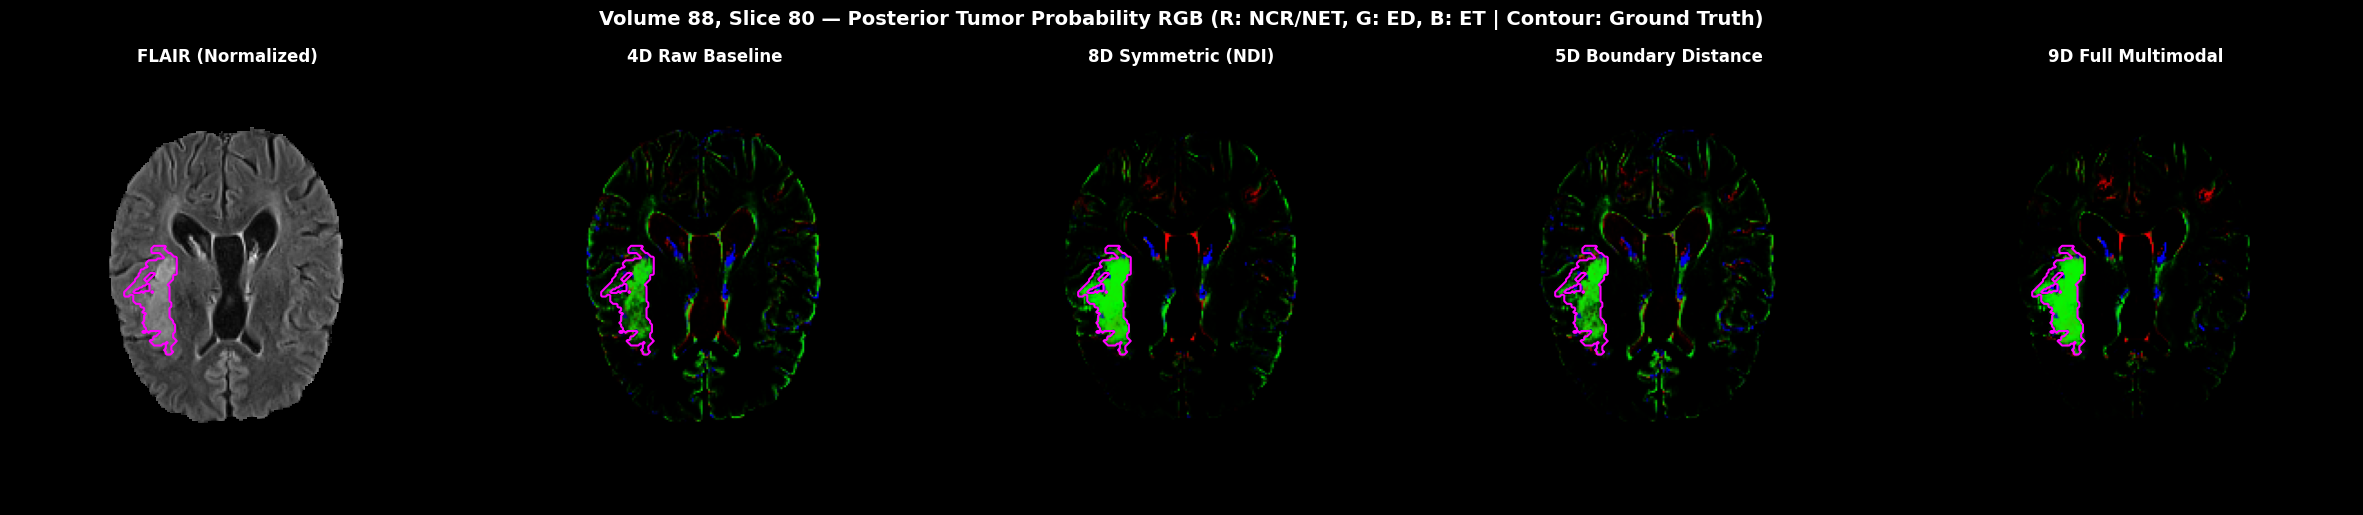

In [15]:

test_tumors = split_table[(split_table["split"] == "test") & (split_table["tumor_pixels"] > 0)].sort_values("tumor_pixels")
posterior_example = int(test_tumors.iloc[len(test_tumors) // 4]["volume"])
plot_posterior_comparison(
    vol_num=posterior_example,
    slice_num=SLICE_NUM,
    modality_idx=0,
    modality_name="FLAIR (Normalized)",
)

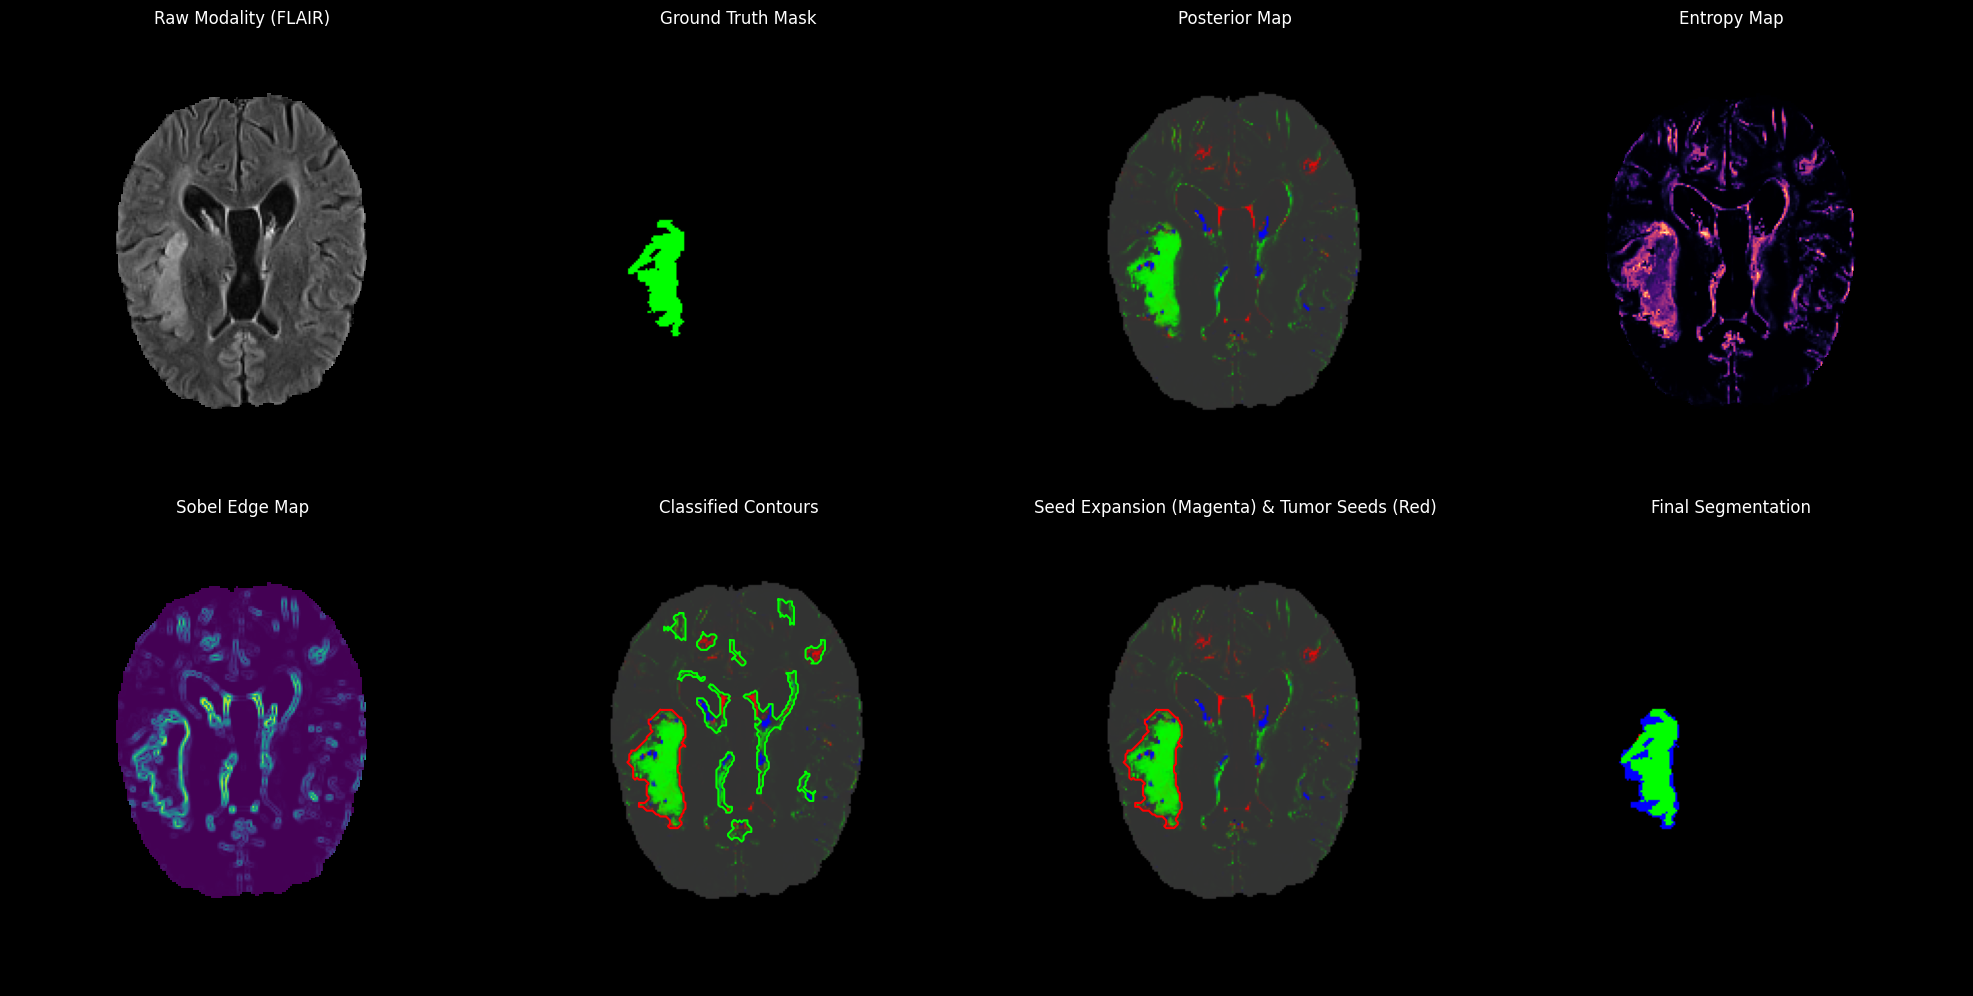

In [16]:
_ = eval_vol(posterior_example, return_details=True, show_plots=True, **MODEL_SPECS["Combined (9D)"])


## 4. Final baseline-versus-improvements comparison

All four models are now frozen. The remaining cells summarize the accumulated
test results and provide every quantitative and qualitative output requested
by the assignment.

### Final test-set evaluation

The assignment requires per-test-sample Dice and IoU, their mean and standard
deviation, separate Dice and IoU boxplots, paired baseline-versus-model scatterplots
with Pearson correlation, and four representative qualitative comparisons.

The four models were evaluated immediately after their parameters were frozen.
The following cells summarize those accumulated results. Empty prediction and empty
ground truth are scored as Dice=IoU=1 because
the tumor-free slice was correctly classified.

### Boxplots

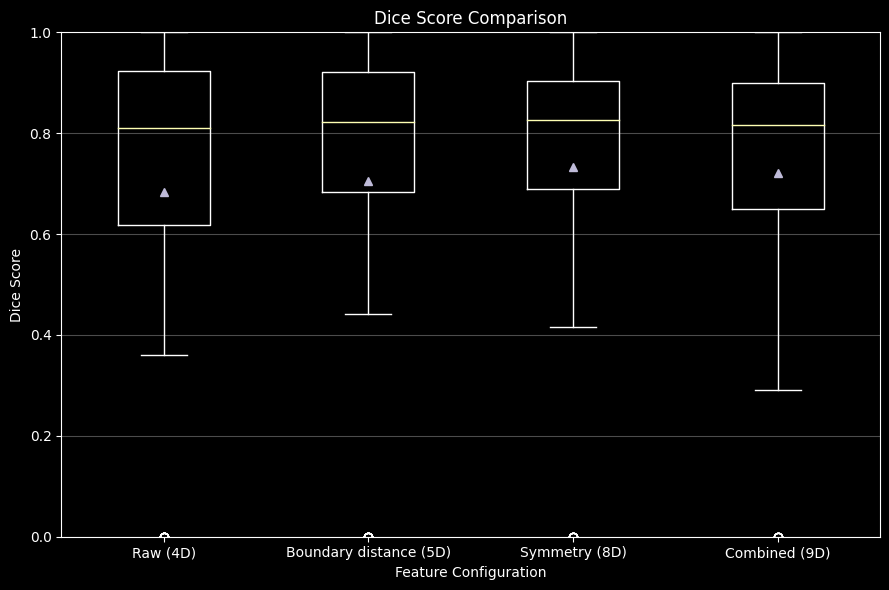

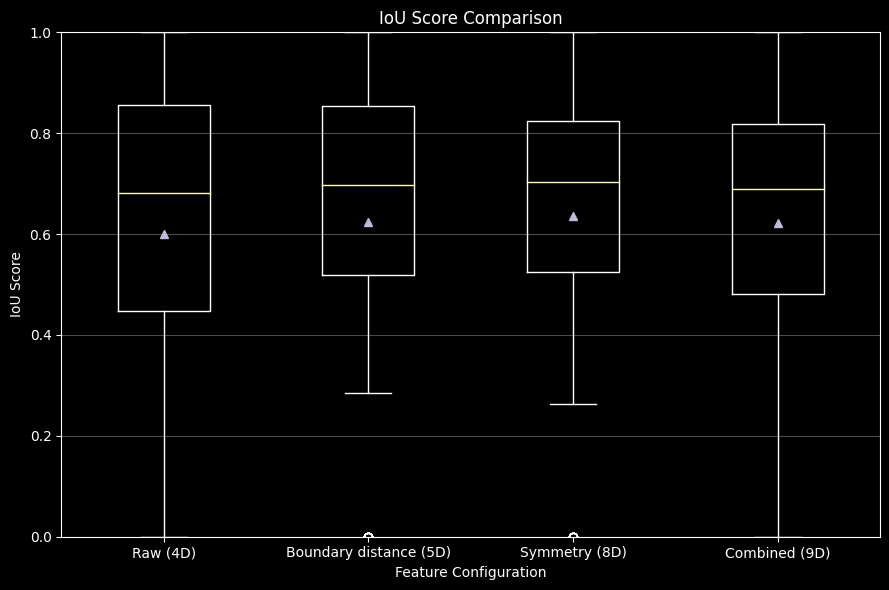

In [17]:
dice_scores = {
    name: result["dice_per_volume"]
    for name, result in RESULTS.items()
}
iou_scores = {
    name: result["iou_per_volume"]
    for name, result in RESULTS.items()
}
plot_segmentation_boxplots(dice_scores, iou_scores)

### Paired performance scatter plots

Every point represents the same test volume under the baseline and one improved model. The dashed diagonal indicates equal performance. Pearson $r$ measures whether the models succeed and fail on similar patients; it does not by itself measure improvement.

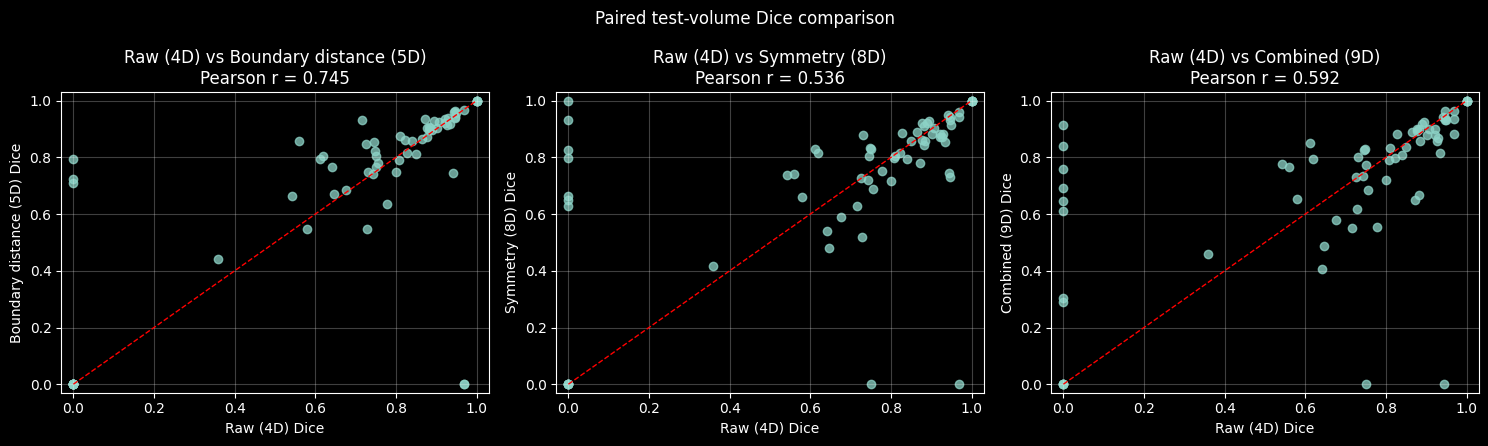

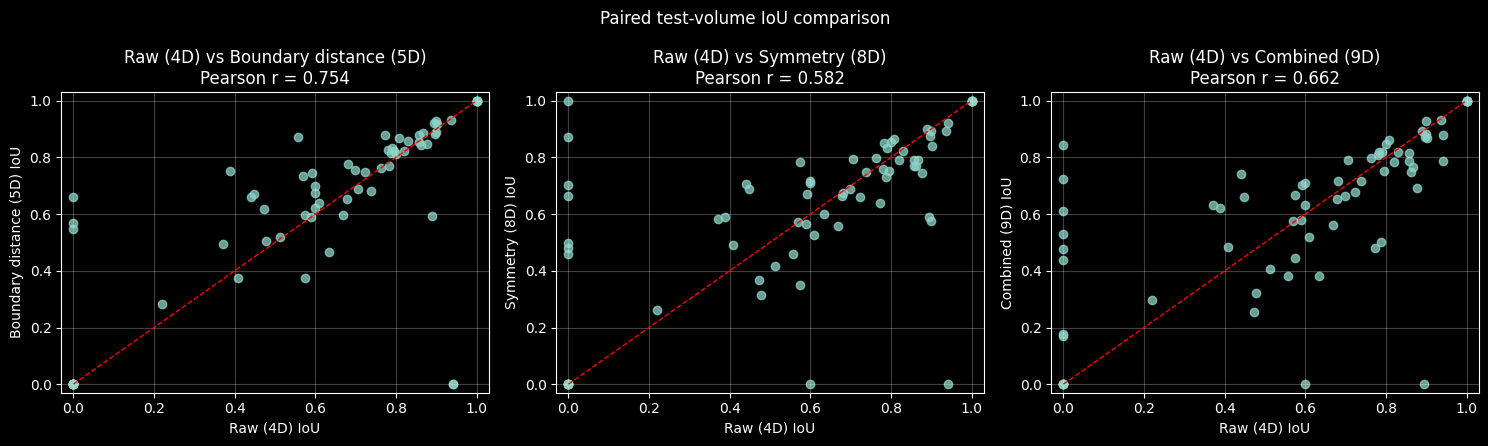

In [18]:
baseline_name = "Raw (4D)"
for metric_key, metric_label in [
    ("dice_per_volume", "Dice"),
    ("iou_per_volume", "IoU"),
]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    baseline_scores = RESULTS[baseline_name][metric_key]
    for axis, model_name in zip(axes, list(RESULTS)[1:]):
        model_scores = RESULTS[model_name][metric_key]
        r, _ = pearsonr(baseline_scores, model_scores)
        axis.scatter(baseline_scores, model_scores, alpha=0.75)
        axis.plot([0, 1], [0, 1], "r--", linewidth=1)
        axis.set(
            xlim=(-0.03, 1.03),
            ylim=(-0.03, 1.03),
            xlabel=f"{baseline_name} {metric_label}",
            ylabel=f"{model_name} {metric_label}",
            title=f"{baseline_name} vs {model_name}\nPearson r = {r:.3f}",
        )
        axis.grid(alpha=0.25)
    fig.suptitle(f"Paired test-volume {metric_label} comparison")
    plt.tight_layout()
    plt.show()

### Baseline and improved-model results table

In [19]:
results_table = pd.DataFrame([
    {
        "Model": model_name,
        "Dice mean": result["mean_dice"],
        "Dice std": result["std_dice"],
        "Tumor-present Dice": result["tumor_present_mean_dice"],
        "Precision": result["tumor_present_mean_precision"],
        "Recall": result["tumor_present_mean_recall"],
        "IoU mean": result["mean_iou"],
        "IoU std": result["std_iou"],
        "Missed tumors": f'{result["missed_tumors_count"]}/{result["gt_tumors_count"]}',
        "Empty-slice FP": f'{result["tumor_free_false_positives"]}/{result["tumor_free_count"]}',
    }
    for model_name, result in RESULTS.items()
])
results_table.to_csv(Path(PROJECT_ROOT) / "output" / "test_results.csv", index=False)
display(results_table.round(4))

error_case_table = pd.DataFrame([
    {
        "Model": model_name,
        "Missed tumor count": result["missed_tumors_count"],
        "Missed tumor volumes": result["missed_volume_numbers"].tolist(),
        "Empty-slice FP count": result["tumor_free_false_positives"],
        "False-positive volumes": result["false_positive_volume_numbers"].tolist(),
    }
    for model_name, result in RESULTS.items()
])
error_case_table.to_csv(
    Path(PROJECT_ROOT) / "output" / "test_error_cases.csv", index=False
)
display(error_case_table)

per_volume_metrics = pd.DataFrame({"Volume": RESULTS["Raw (4D)"]["volume_numbers"]})
for model_name, result in RESULTS.items():
    per_volume_metrics[f"{model_name} Dice"] = result["dice_per_volume"]
    per_volume_metrics[f"{model_name} IoU"] = result["iou_per_volume"]
per_volume_metrics.to_csv(
    Path(PROJECT_ROOT) / "output" / "test_per_volume_metrics.csv", index=False
)
print("Per-test-volume Dice and IoU:")
with pd.option_context("display.max_rows", None):
    display(per_volume_metrics.round(4))

,Model,Dice mean,Dice std,Tumor-present Dice,Precision,Recall,IoU mean,IoU std,Missed tumors,Empty-slice FP
0,Raw (4D),0.6828,0.3373,0.6793,0.6604,0.7450,0.5998,0.3231,10/62,2/7
1,Boundary distance (5D),0.7061,0.3270,0.7052,0.6986,0.7592,0.6234,0.3123,9/62,2/7
2,Symmetry (8D),0.7323,0.2769,0.7182,0.6845,0.8079,0.6361,0.2737,6/62,1/7
3,Combined (9D),0.7215,0.2732,0.7223,0.6880,0.8154,0.6218,0.2751,4/62,2/7


,Model,Missed tumor count,Missed tumor volumes,Empty-slice FP count,False-positive volumes
0,Raw (4D),10,"[300, 219, 82, 308, 150, 202, 23, 78, 287, 110]",2,"[360, 28]"
1,Boundary distance (5D),9,"[300, 82, 308, 257, 23, 78, 287, 110, 333]",2,"[360, 28]"
2,Symmetry (8D),6,"[82, 257, 279, 23, 287, 110]",1,[28]
3,Combined (9D),4,"[197, 279, 287, 110]",2,"[360, 28]"


Per-test-volume Dice and IoU:


,Volume,Raw (4D) Dice,Raw (4D) IoU,Boundary distance (5D) Dice,Boundary distance (5D) IoU,Symmetry (8D) Dice,Symmetry (8D) IoU,Combined (9D) Dice,Combined (9D) IoU
0,243,0.8855,0.7945,0.9033,0.8237,0.8587,0.7524,0.8585,0.7520
1,75,0.8942,0.8086,0.9299,0.8690,0.9282,0.8660,0.9257,0.8617
2,163,0.9473,0.8998,0.9629,0.9284,0.9433,0.8927,0.9630,0.9286
3,347,0.9065,0.8290,0.9240,0.8587,0.9032,0.8234,0.9014,0.8206
4,97,0.8108,0.6818,0.8746,0.7772,0.8055,0.6743,0.8338,0.7149
5,50,0.5602,0.3891,0.8575,0.7506,0.7412,0.5888,0.7654,0.6200
6,300,0.0000,0.0000,0.0000,0.0000,0.7989,0.6651,0.6934,0.5307
7,183,0.9412,0.8890,0.7451,0.5938,0.9480,0.9011,0.9430,0.8921
8,289,0.9228,0.8566,0.9209,0.8533,0.8829,0.7903,0.8983,0.8154
9,152,0.8781,0.7827,0.8702,0.7703,0.9197,0.8513,0.9002,0.8185


## Failure analysis

The first table above gives both the number and exact volume identifiers of completely
missed tumors and tumor-free false positives for every model. The plots below examine
whether failures are associated with tumor size, compare the missed-case overlap between
models, and visualize true-positive, false-positive and false-negative regions.

Completely missed tumor volumes for Combined (9D):


,Volume,Dice,Precision,Recall,Ground-truth pixels,Predicted pixels,Tumor present
11,197,0.0,0.0,0.0,3071,0,True
34,279,0.0,0.0,0.0,3205,0,True
56,287,0.0,0.0,0.0,3,0,True
58,110,0.0,0.0,0.0,30,719,True


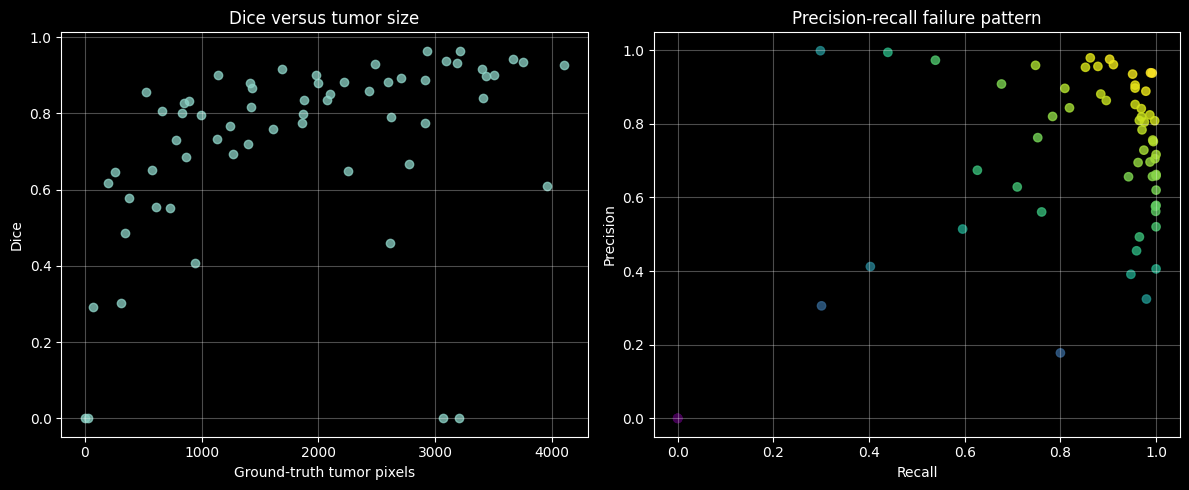

In [20]:
final_model_name = "Combined (9D)"
final_result = RESULTS[final_model_name]
tumor_present = final_result["tumor_present"]
diagnostic_table = pd.DataFrame({
    "Volume": final_result["volume_numbers"],
    "Dice": final_result["dice_per_volume"],
    "Precision": final_result["precision_per_volume"],
    "Recall": final_result["recall_per_volume"],
    "Ground-truth pixels": final_result["gt_size_per_volume"],
    "Predicted pixels": final_result["pred_size_per_volume"],
    "Tumor present": tumor_present,
})
missed_table = diagnostic_table[tumor_present & (diagnostic_table["Recall"] == 0)]
print(f"Completely missed tumor volumes for {final_model_name}:")
display(missed_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
present_data = diagnostic_table[tumor_present]
axes[0].scatter(present_data["Ground-truth pixels"], present_data["Dice"], alpha=0.75)
axes[0].set(xlabel="Ground-truth tumor pixels", ylabel="Dice", title="Dice versus tumor size")
axes[1].scatter(
    present_data["Recall"], present_data["Precision"],
    c=present_data["Dice"], cmap="viridis", alpha=0.8,
)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall failure pattern")
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "failure_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
def normalize_for_display(image, brain_mask):
    values = image[brain_mask]
    low, high = np.percentile(values, [1, 99])
    return np.clip((image - low) / max(high - low, 1e-8), 0, 1)

def error_overlay(ground_truth, prediction):
    overlay = np.zeros((*ground_truth.shape, 4), dtype=float)
    overlay[ground_truth & prediction] = (0.15, 0.90, 0.25, 0.75)
    overlay[~ground_truth & prediction] = (1.00, 0.20, 0.10, 0.75)
    overlay[ground_truth & ~prediction] = (0.10, 0.45, 1.00, 0.85)
    return overlay

def mark_ground_truth_location(axis, ground_truth, margin=4):
    rows, columns = np.where(ground_truth)
    if len(rows) == 0:
        return
    x0, x1 = max(columns.min() - margin, 0), min(columns.max() + margin, ground_truth.shape[1] - 1)
    y0, y1 = max(rows.min() - margin, 0), min(rows.max() + margin, ground_truth.shape[0] - 1)
    axis.add_patch(Rectangle((x0, y0), x1 - x0 + 1, y1 - y0 + 1, fill=False, edgecolor="yellow", linewidth=1.2))

missed_sets = {name: set(map(int, result["missed_volume_numbers"])) for name, result in RESULTS.items()}
all_missed_volumes = sorted(set().union(*missed_sets.values()))
missed_case_details = {
    volume: {name: eval_vol(volume, return_details=True, show_plots=False, **spec) for name, spec in MODEL_SPECS.items()}
    for volume in all_missed_volumes
}
missed_comparison = pd.DataFrame([
    {
        "Volume": volume,
        "Ground-truth pixels": next(iter(cases.values()))["gt_size"],
        **{f"{name} Dice": cases[name]["dice"] for name in MODEL_SPECS},
        "Completely missed by": ", ".join(name for name in MODEL_SPECS if volume in missed_sets[name]),
    }
    for volume, cases in missed_case_details.items()
])
display(missed_comparison.round(3))

,Volume,Ground-truth pixels,Raw (4D) Dice,Boundary distance (5D) Dice,Symmetry (8D) Dice,Combined (9D) Dice,Completely missed by
0,23,306,0.000,0.000,0.000,0.303,"Raw (4D), Boundary distance (5D), Symmetry (8D)"
1,78,255,0.000,0.000,0.663,0.646,"Raw (4D), Boundary distance (5D)"
2,82,70,0.000,0.000,0.000,0.291,"Raw (4D), Boundary distance (5D), Symmetry (8D)"
3,110,30,0.000,0.000,0.000,0.000,"Raw (4D), Boundary distance (5D), Symmetry (8D..."
4,150,3409,0.000,0.709,0.825,0.840,Raw (4D)
5,197,3071,0.944,0.958,0.743,0.000,Combined (9D)
6,202,1686,0.000,0.725,0.932,0.916,Raw (4D)
7,219,1613,0.000,0.796,0.650,0.758,Raw (4D)
8,257,2217,0.970,0.000,0.000,0.882,"Boundary distance (5D), Symmetry (8D)"
9,279,3205,0.750,0.767,0.000,0.000,"Symmetry (8D), Combined (9D)"


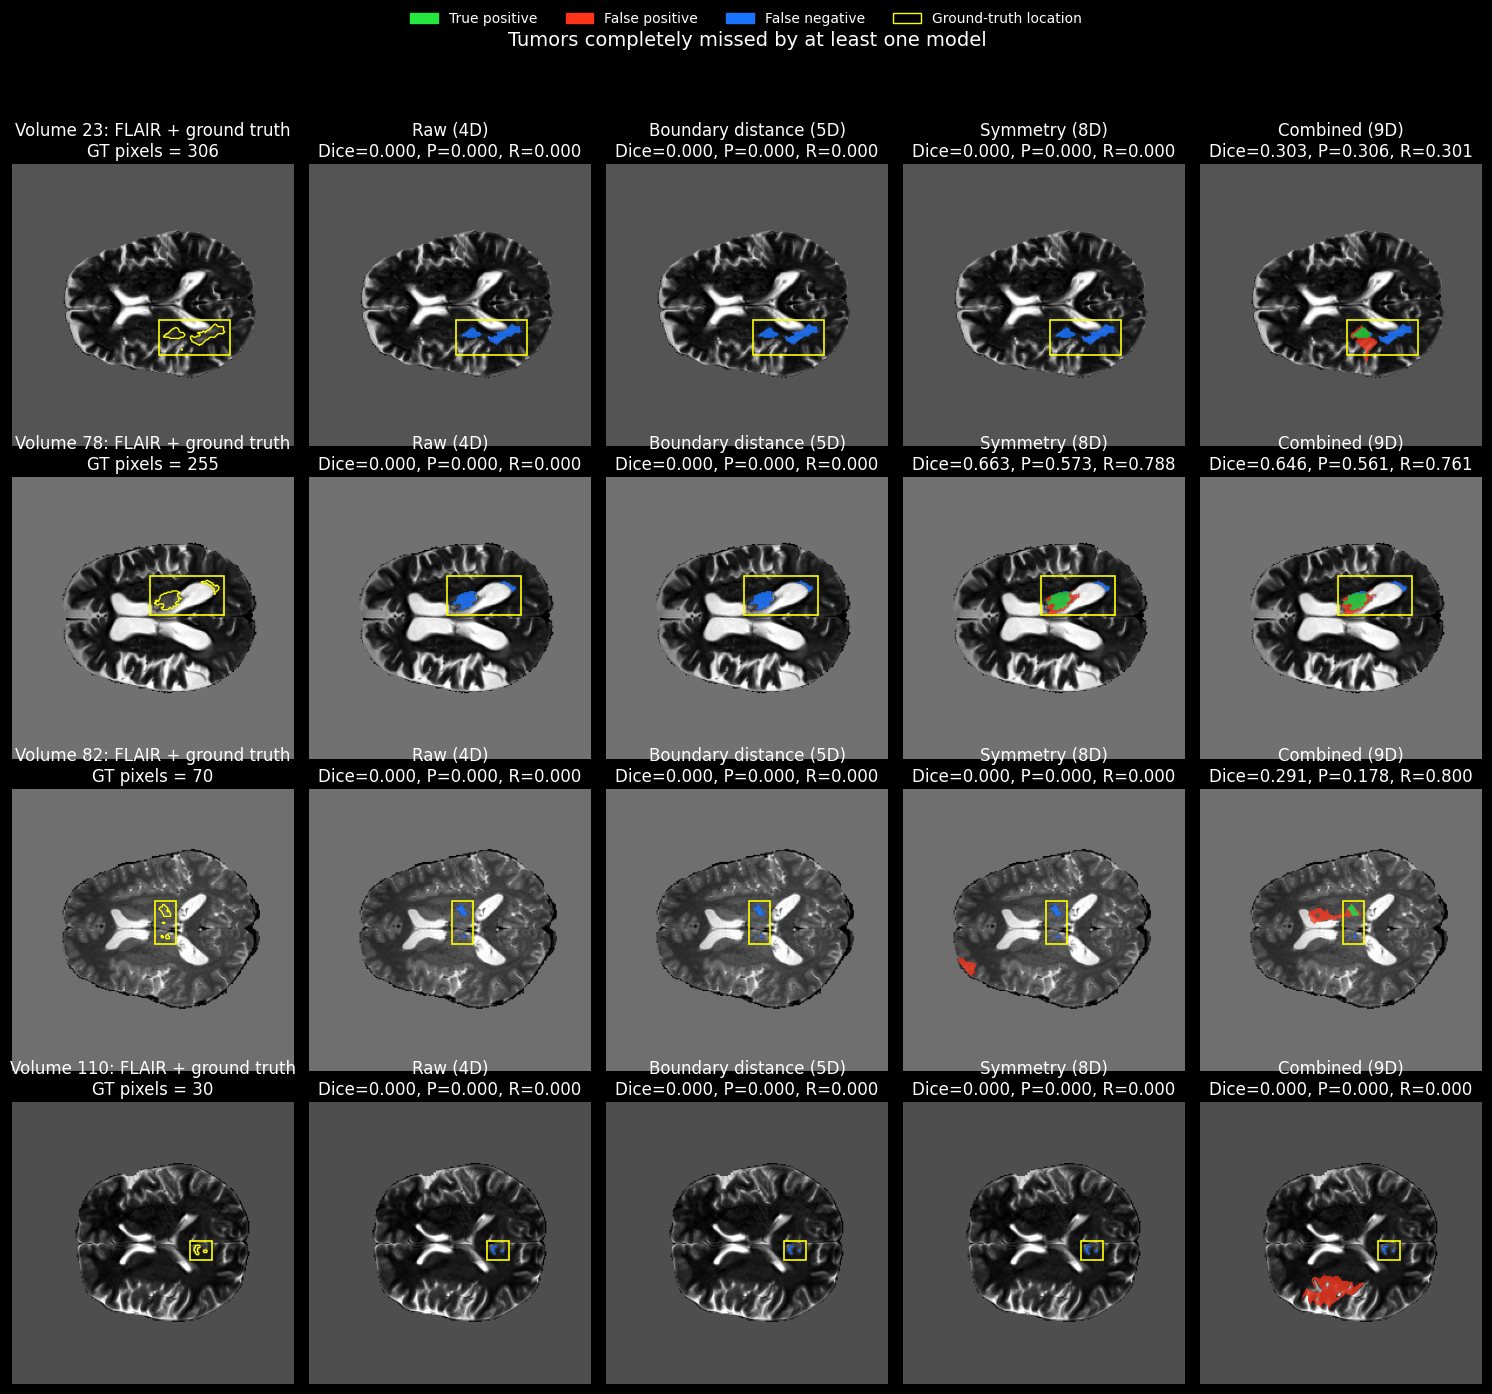

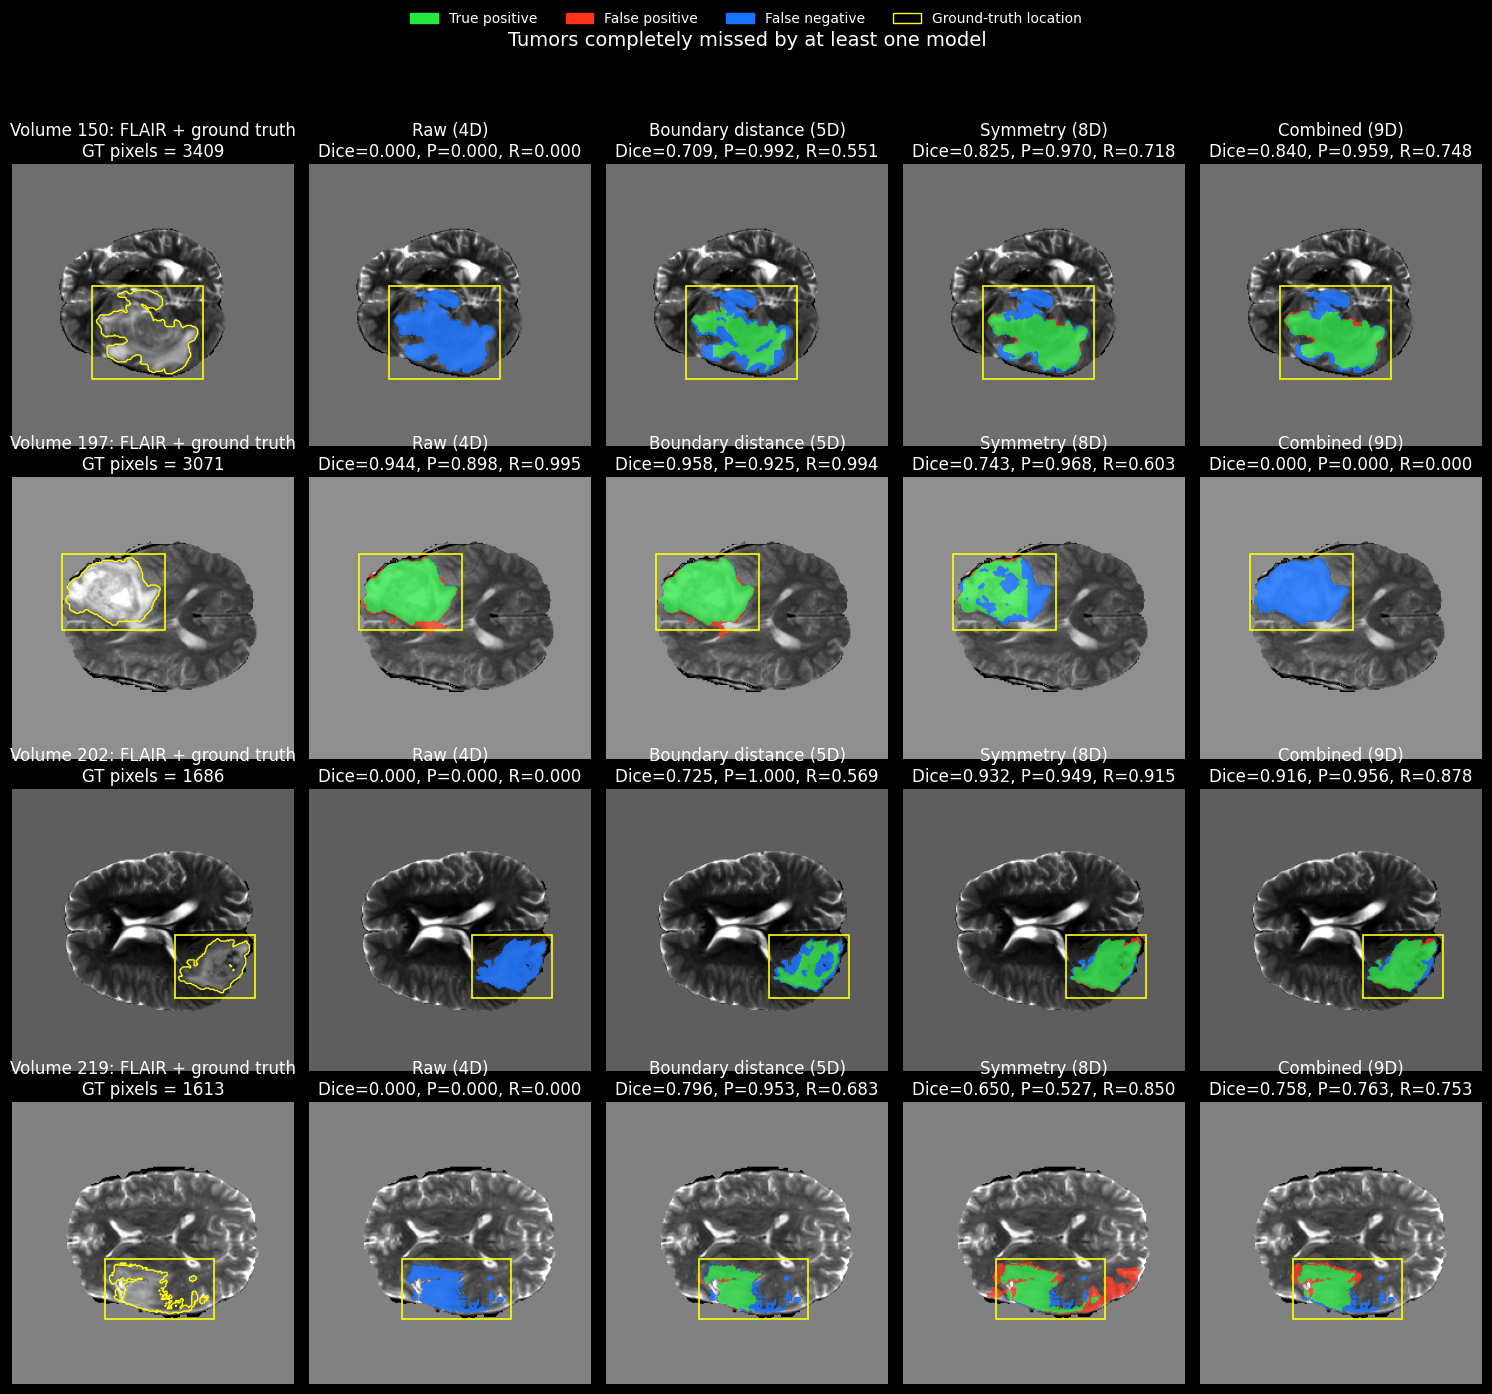

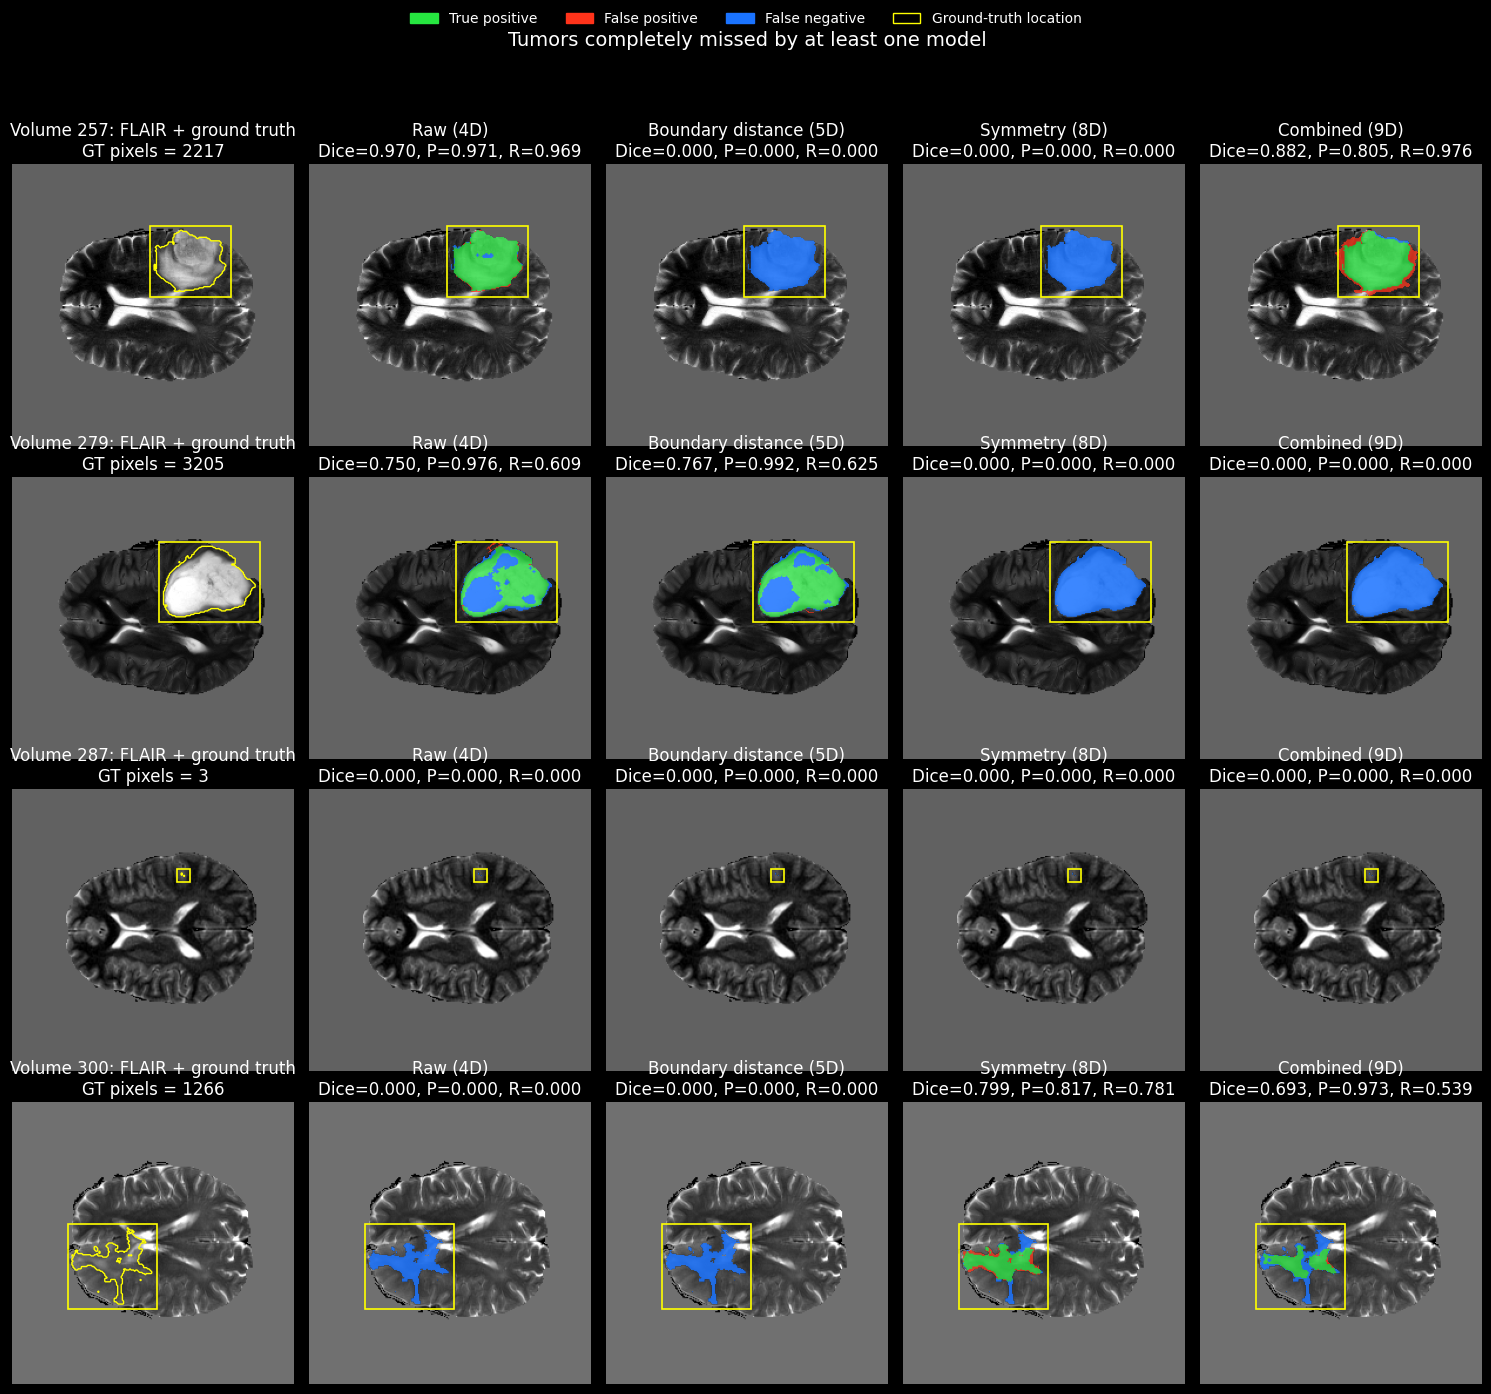

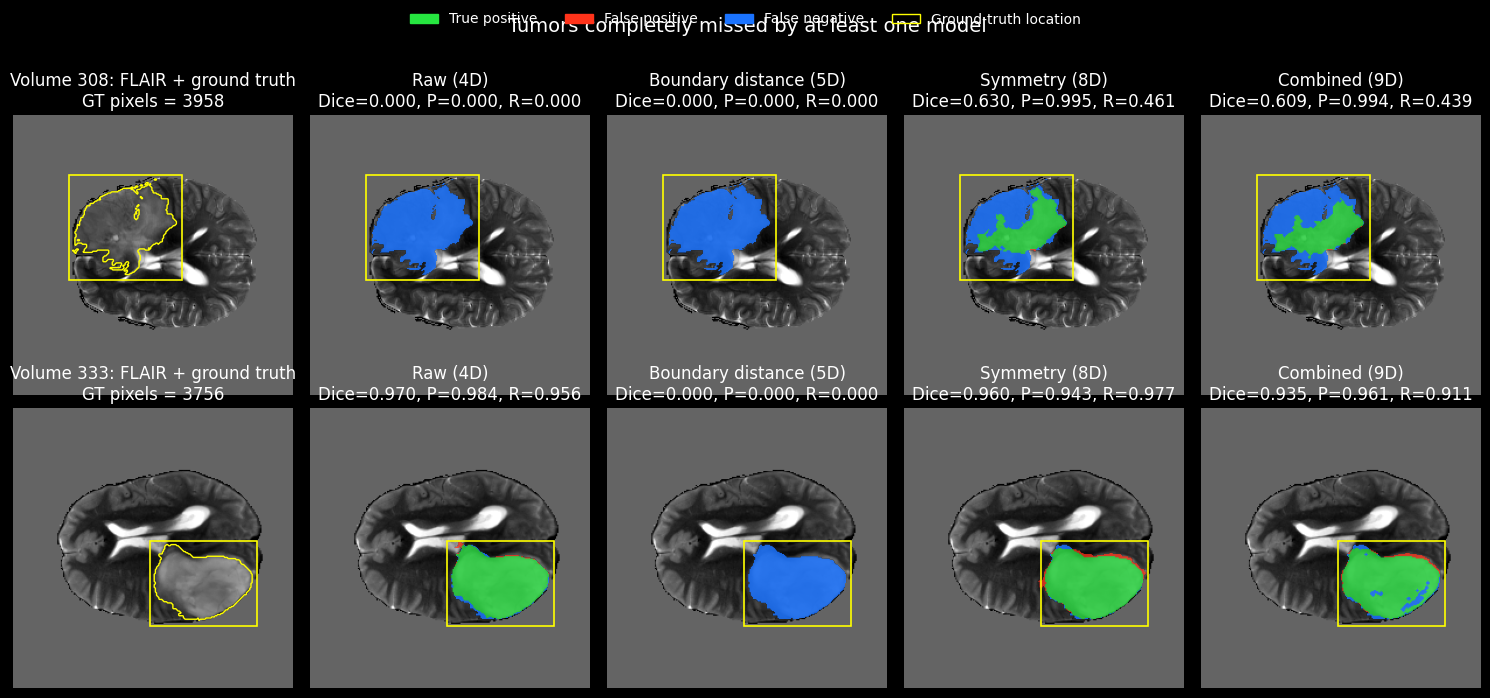

In [22]:
model_names = list(MODEL_SPECS)
rows_per_figure = 4
legend = [
    Patch(color=(0.15, 0.90, 0.25), label="True positive"),
    Patch(color=(1.00, 0.20, 0.10), label="False positive"),
    Patch(color=(0.10, 0.45, 1.00), label="False negative"),
    Patch(facecolor="none", edgecolor="yellow", label="Ground-truth location"),
]

for page, start in enumerate(range(0, len(all_missed_volumes), rows_per_figure), start=1):
    page_volumes = all_missed_volumes[start:start + rows_per_figure]
    fig, axes = plt.subplots(len(page_volumes), 1 + len(model_names), figsize=(15, 3.5 * len(page_volumes)), squeeze=False)
    for row, volume in enumerate(page_volumes):
        cases = missed_case_details[volume]
        reference = cases[model_names[0]]
        ground_truth = reference["ground_truth"]
        flair = normalize_for_display(reference["image"][:, :, 3], reference["brain_mask"])
        axes[row, 0].imshow(flair, cmap="gray")
        axes[row, 0].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=1)
        mark_ground_truth_location(axes[row, 0], ground_truth)
        axes[row, 0].set_title(f"Volume {volume}: FLAIR + ground truth\nGT pixels = {reference['gt_size']}")

        for column, model_name in enumerate(model_names, start=1):
            details = cases[model_name]
            axes[row, column].imshow(flair, cmap="gray")
            axes[row, column].imshow(error_overlay(ground_truth, details["prediction"]))
            mark_ground_truth_location(axes[row, column], ground_truth)
            axes[row, column].set_title(f"{model_name}\nDice={details['dice']:.3f}, P={details['precision']:.3f}, R={details['recall']:.3f}")

        for axis in axes[row]:
            axis.axis("off")

    fig.legend(handles=legend, loc="upper center", ncol=4, frameon=False)
    fig.suptitle("Tumors completely missed by at least one model", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(FIGURES_DIR / f"missed_tumor_error_maps_{page}.png", dpi=220, bbox_inches="tight")
    plt.show()

## Required qualitative examples

The four required categories are selected from tumor-present test slices. Each row
shows the FLAIR input, all four model outputs and the ground-truth annotation. If no
case exists where the baseline outperforms the combined model, the notebook states
that explicitly.

In [23]:
def first_unused(order, used):
    return next((int(index) for index in order if int(index) not in used), None)

base_dice = RESULTS["Raw (4D)"]["dice_per_volume"]
final_dice = RESULTS["Combined (9D)"]["dice_per_volume"]
tumor_indices = np.where(RESULTS["Combined (9D)"]["tumor_present"])[0]
used_indices = set()
case_indices = {}

case_orders = {
    "Both performed well": tumor_indices[np.argsort(-np.minimum(base_dice[tumor_indices], final_dice[tumor_indices]))],
    "Both performed poorly": tumor_indices[np.argsort(np.maximum(base_dice[tumor_indices], final_dice[tumor_indices]))],
}
for label, order in case_orders.items():
    selected = first_unused(order, used_indices)
    case_indices[label] = selected
    used_indices.add(selected)

for label, difference in [
    ("Baseline performed better", base_dice - final_dice),
    ("Combined (9D) performed better", final_dice - base_dice),
]:
    valid_difference = difference[tumor_indices]
    if np.max(valid_difference) <= 0:
        case_indices[label] = None
        print(f"No tumor-present test case where {label.lower()}.")
    else:
        order = tumor_indices[np.argsort(-valid_difference)]
        selected = first_unused(order, used_indices)
        case_indices[label] = selected
        used_indices.add(selected)

selected_cases = {
    label: int(RESULTS["Raw (4D)"]["volume_numbers"][index])
    for label, index in case_indices.items()
    if index is not None
}
display(pd.DataFrame(selected_cases.items(), columns=["Category", "Volume"]))

,Category,Volume
0,Both performed well,254
1,Both performed poorly,110
2,Baseline performed better,197
3,Combined (9D) performed better,202


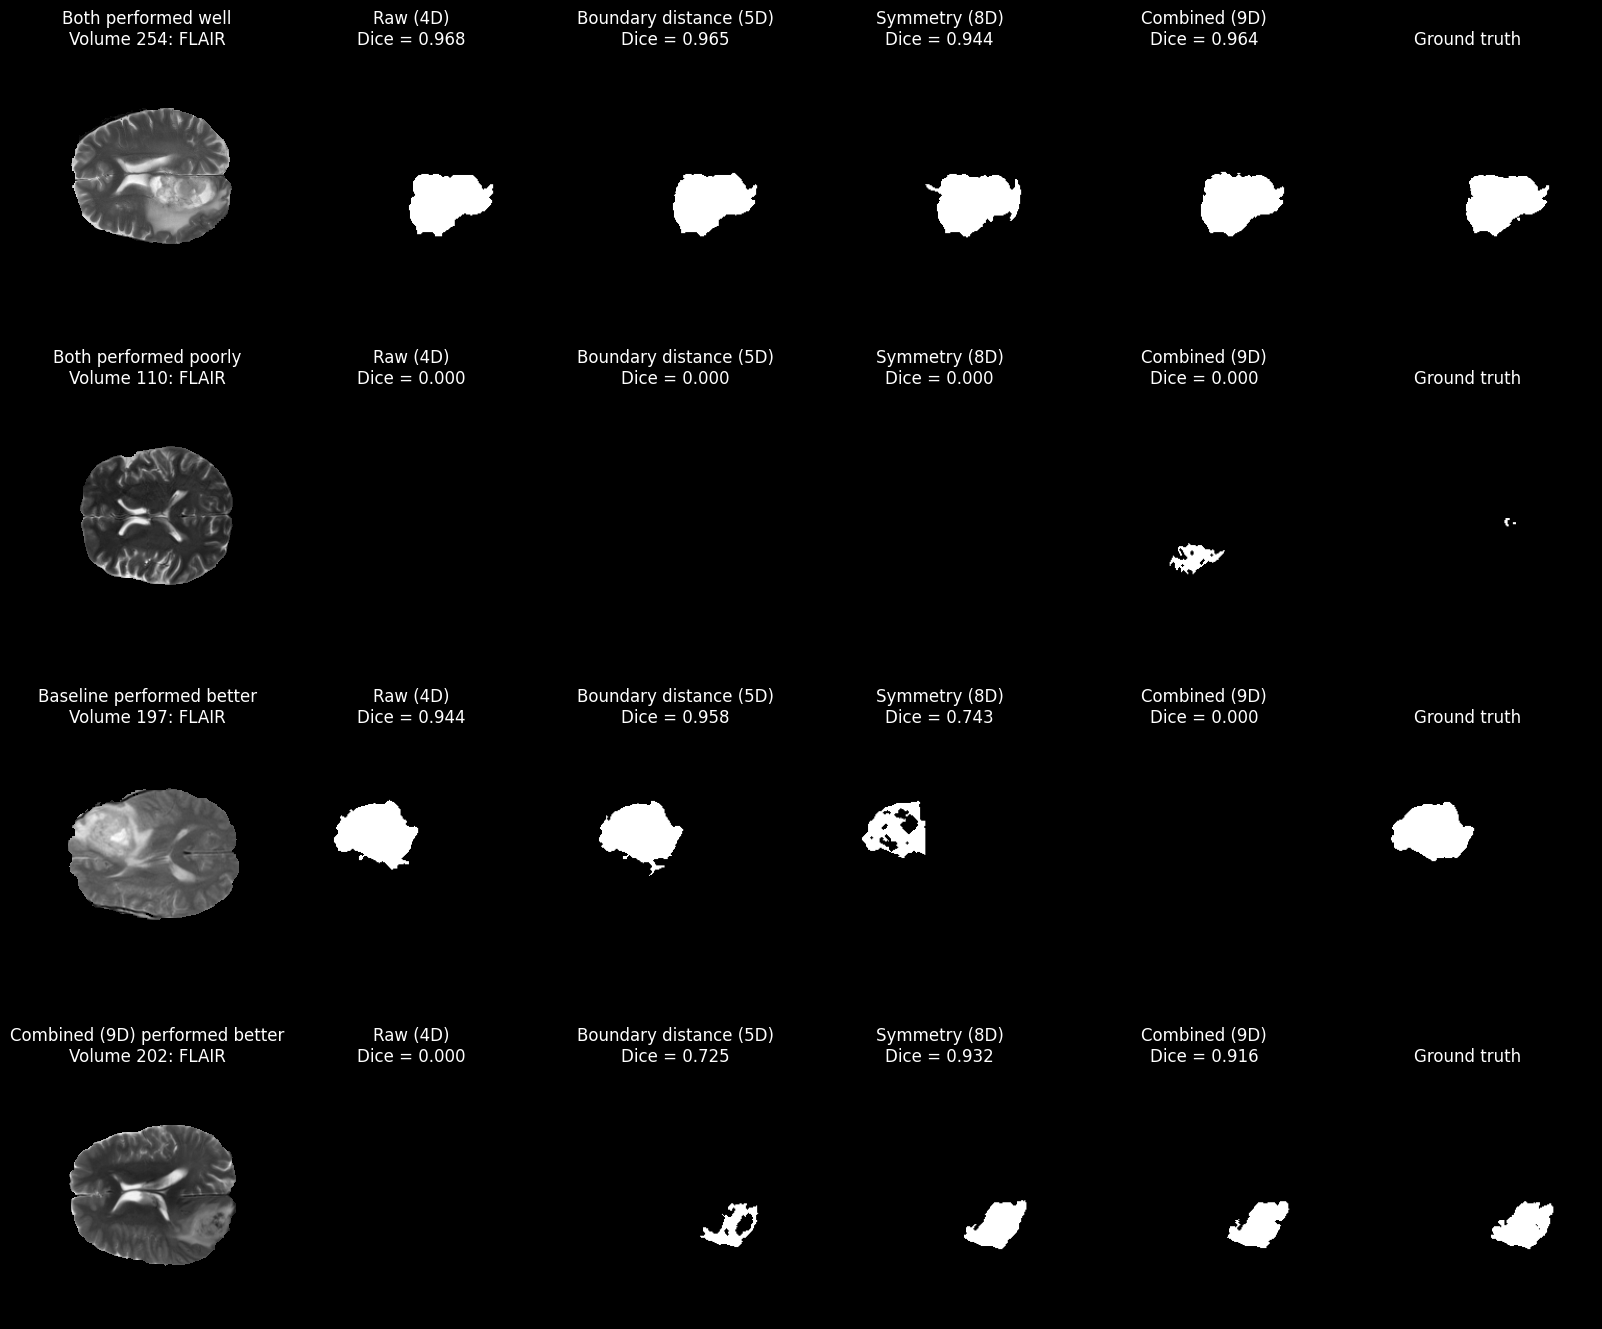

,Category,Volume,Raw Dice,Combined Dice,Short explanation
0,Both performed well,254,0.968,0.964,"Both methods delineate this tumor well, indica..."
1,Both performed poorly,110,0.000,0.000,Both methods struggle on this case; inspect tu...
2,Baseline performed better,197,0.944,0.000,The raw-intensity baseline retains more correc...
3,Combined (9D) performed better,202,0.000,0.916,The symmetry and boundary-distance features im...


In [24]:
fig, axes = plt.subplots(len(selected_cases), 2 + len(MODEL_SPECS), figsize=(16, 3.5 * len(selected_cases)), squeeze=False)

for row, (category, volume) in enumerate(selected_cases.items()):
    predictions = {
        label: eval_vol(volume, return_details=True, show_plots=False, **spec)
        for label, spec in MODEL_SPECS.items()
    }
    reference = predictions["Raw (4D)"]
    axes[row, 0].imshow(np.where(reference["brain_mask"], reference["image"][:, :, 3], np.nan), cmap="gray")
    axes[row, 0].set_title(f"{category}\nVolume {volume}: FLAIR")

    for column, label in enumerate(MODEL_SPECS, start=1):
        details = predictions[label]
        axes[row, column].imshow(details["prediction"], cmap="gray")
        axes[row, column].set_title(f"{label}\nDice = {details['dice']:.3f}")

    axes[row, -1].imshow(reference["ground_truth"], cmap="gray")
    axes[row, -1].set_title("Ground truth")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "qualitative_examples.png", dpi=300, bbox_inches="tight")
plt.show()

explanation_templates = {
    "Both performed well": "Both methods delineate this tumor well, indicating strong multimodal contrast and a stable contour.",
    "Both performed poorly": "Both methods struggle on this case; inspect tumor size, contrast and boundary ambiguity in the error maps.",
    "Baseline performed better": "The raw-intensity baseline retains more correct tumor pixels than the combined anatomical representation.",
    "Combined (9D) performed better": "The symmetry and boundary-distance features improve the combined model relative to raw intensities.",
}
qualitative_explanations = []
for category, volume in selected_cases.items():
    baseline = eval_vol(volume, return_details=True, show_plots=False, **MODEL_SPECS["Raw (4D)"])
    combined = eval_vol(volume, return_details=True, show_plots=False, **MODEL_SPECS["Combined (9D)"])
    qualitative_explanations.append({
        "Category": category,
        "Volume": volume,
        "Raw Dice": baseline["dice"],
        "Combined Dice": combined["dice"],
        "Short explanation": explanation_templates[category],
    })
display(pd.DataFrame(qualitative_explanations).round(3))

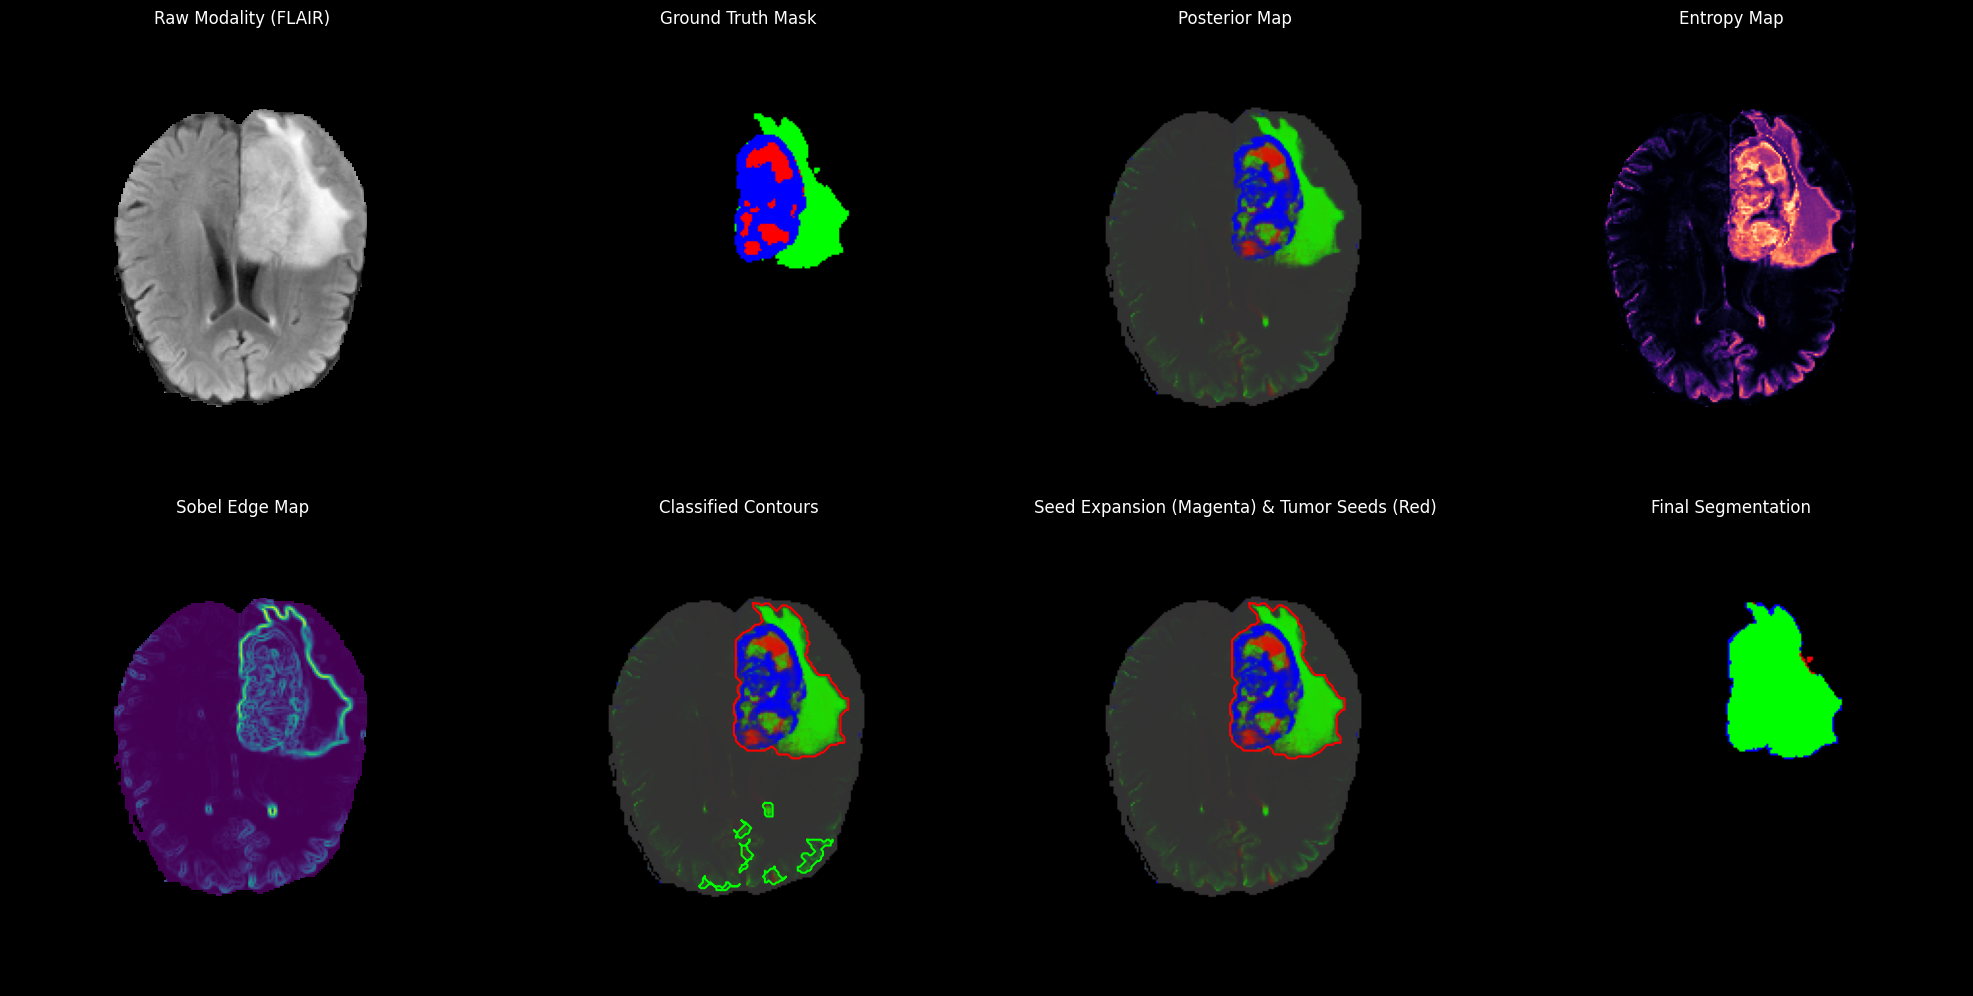

In [29]:
_ = eval_vol(254, return_details=True, show_plots=True, **MODEL_SPECS["Raw (4D)"])


## Summary and interpretation

The Raw 4D model is the classical baseline. Boundary distance, symmetry and their
combination are evaluated as successive statistical improvements under the same
baseline-selected spatial processing. Therefore, their differences from the baseline
cannot be attributed to separately tuned contour geometry.

In [25]:
best_model = results_table.loc[results_table["Dice mean"].idxmax(), "Model"]
baseline_mean = RESULTS["Raw (4D)"]["mean_dice"]

print(f"Highest mean test Dice: {best_model}")
for model_name in list(RESULTS)[1:]:
    difference = RESULTS[model_name]["mean_dice"] - baseline_mean
    direction = "improvement" if difference > 0 else "decrease"
    print(f"{model_name}: {direction} of {difference:+.4f} Dice relative to Raw (4D)")

Highest mean test Dice: Symmetry (8D)
Boundary distance (5D): improvement of +0.0233 Dice relative to Raw (4D)
Symmetry (8D): improvement of +0.0495 Dice relative to Raw (4D)
Combined (9D): improvement of +0.0386 Dice relative to Raw (4D)
